# Data visualization

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/data_viz.ipynb)

This notebook demonstrates how to work with geospatial imagery data using TorchGeo and GeoAI. We'll explore how to load data, sample it using different strategies, and visualize the results.

## Install Package
To use the `geoai-py` package, ensure it is installed in your environment. Uncomment the command below if needed.

In [ ]:
# %pip install geoai-py

## Importing Required Libraries

First, we import the necessary libraries for our geospatial data visualization workflow:

In [1]:
from torchgeo.datasets import NAIP
from torchgeo.samplers import RandomGeoSampler, GridGeoSampler
from geoai.utils import view_image, view_raster, dict_to_image
from geoai.download import download_naip

## Download NAIP imagery

In [2]:
root = "naip_data"

In [3]:
bbox = (-117.6029, 47.65, -117.5936, 47.6563)
downloaded_files = download_naip(
    bbox=bbox,
    output_dir=root,
    max_items=1,
)

- **torchgeo.datasets.NAIP**: Provides access to the National Agriculture Imagery Program (NAIP) dataset, which offers high-resolution aerial imagery across the United States.
- **torchgeo.samplers**: Contains sampling strategies for geospatial data:
  - **RandomGeoSampler**: Samples random patches from the dataset
  - **GridGeoSampler**: Samples patches in a grid pattern with specified stride
- **geoai.utils**: Custom utility functions for visualization:
  - **view_image**: Visualizes tensor images
  - **view_raster**: Displays georeferenced data on an interactive map
  - **dict_to_image**: Converts dictionary representation to image format

## Setting Up the Dataset

Load the NAIP dataset from the specified root directory:

In [4]:
dataset = NAIP(root)

Examine the dataset object to understand its properties:

In [5]:
dataset

This will display information about the NAIP dataset including available imagery dates, coverage area, and other metadata.

Check the Coordinate Reference System (CRS) used by the dataset:

In [6]:
dataset.crs

<Projected CRS: EPSG:26911>
Name: NAD83 / UTM zone 11N
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

The CRS defines how the geospatial data is projected onto a coordinate system, which is essential for accurate visualization and analysis.

## Random Sampling of Geospatial Data

Create a random sampler to extract patches from the dataset:

In [7]:
train_sampler = RandomGeoSampler(dataset, size=256, length=1000)

This creates a sampler that will randomly select 1000 patches, each 256x256 pixels in size. This sampling strategy is commonly used for training machine learning models where you need a diverse set of examples.

Extract a bounding box from the random sampler:

In [8]:
train_bbox = next(iter(train_sampler))
train_bbox

(slice(453521.4, 453675.0, None),
 slice(5279393.4, 5279547.0, None),
 slice(Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 23:59:59.999999'), None))

The bounding box contains the coordinates defining the spatial extent of our randomly sampled patch.

Load the actual image data corresponding to the randomly selected bounding box:

In [9]:
train_image = dataset[next(iter(train_sampler))]["image"]

Examine the complete data dictionary returned for a sample, which includes both the image and metadata:

In [10]:
dataset[next(iter(train_sampler))]

{'crs': <Projected CRS: EPSG:26911>
 Name: NAD83 / UTM zone 11N
 Axis Info [cartesian]:
 - [east]: Easting (metre)
 - [north]: Northing (metre)
 Area of Use:
 - undefined
 Coordinate Operation:
 - name: UTM zone 11N
 - method: Transverse Mercator
 Datum: North American Datum 1983
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich,
 'bounds': (slice(455427.0, 455580.6, None),
  slice(5276720.4, 5276874.0, None),
  slice(Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 23:59:59.999999'), None)),
 'image': tensor([[[157., 186., 199.,  ..., 137., 140., 155.],
          [213., 230., 230.,  ..., 151., 150., 153.],
          [227., 229., 230.,  ..., 140., 135., 144.],
          ...,
          [119., 121., 120.,  ..., 194., 190., 183.],
          [121., 124., 126.,  ..., 191., 189., 183.],
          [122., 127., 125.,  ..., 190., 188., 184.]],
 
         [[144., 171., 186.,  ..., 125., 127., 139.],
          [194., 223., 224.,  ..., 132., 134., 138.],
          [212., 220., 223.,  ...,

This returns a dictionary containing the image tensor and associated metadata such as the bounding box, CRS, and other properties.

## Visualizing Randomly Sampled Data

Display the randomly sampled image:

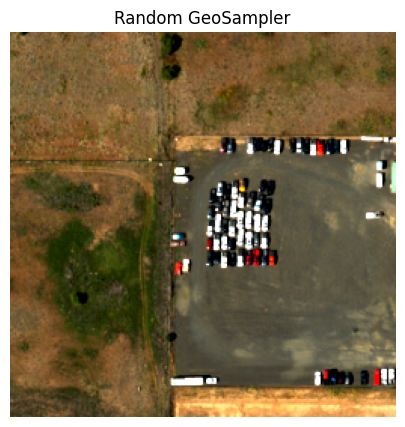

In [12]:
view_image(
    train_image, transpose=True, title="Random GeoSampler"
)

- **transpose=True**: Rearranges the dimensions for proper display (from [C,H,W] to [H,W,C])
- **scale_factor=(1/250)**: Scales the pixel values for better visualization
- **title="Random GeoSampler"**: Adds a descriptive title to the plot

## Grid Sampling of Geospatial Data

Create a grid sampler to extract patches in a systematic pattern:

In [13]:
test_sampler = GridGeoSampler(dataset, size=256, stride=128)

This sampler extracts 256x256 pixel patches in a grid pattern with a stride of 128 pixels, meaning patches will overlap by 128 pixels. Grid sampling is typically used for inference or testing, where systematic coverage of the area is important.

Extract a bounding box from the grid sampler:

In [14]:
test_bbox = next(iter(test_sampler))
test_bbox

(slice(452838.0, 452991.6, None),
 slice(5274576.0, 5274729.6, None),
 slice(Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 23:59:59.999999'), None))

Load the image data for a patch selected by the grid sampler:

In [15]:
test_image = dataset[next(iter(test_sampler))]["image"]

## Visualizing Grid Sampled Data

Display the image from the grid sampler:

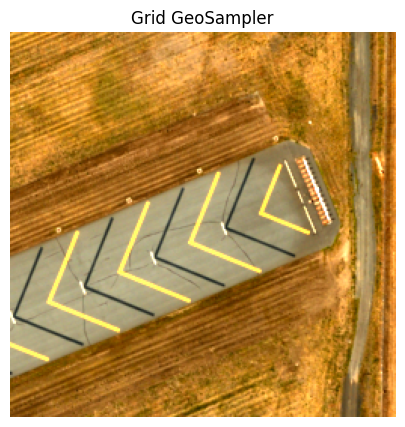

In [17]:
view_image(test_image, transpose=True, title="Grid GeoSampler")

The visualization shows a systematically sampled patch from the dataset.

## Advanced Visualization with Geospatial Context

Load a complete data sample including all metadata:

In [18]:
data = dataset[next(iter(test_sampler))]

Visualize the raster data on an interactive map with Esri.WorldImagery imagery as the background:

In [19]:
view_raster(data, basemap="Esri.WorldImagery")

AttributeError: 'tuple' object has no attribute 'maxx'

This interactive visualization places the sampled data in its real-world geographic context, allowing you to see how it aligns with the Esri.WorldImagery imagery.

## Key Takeaways

1. **TorchGeo** provides a flexible framework for working with geospatial datasets like NAIP.
2. Different sampling strategies (random vs. grid) serve different purposes in geospatial machine learning workflows.
3. Visualization tools help understand the data in both pixel space (view_image) and geographic space (view_raster).
4. Working with geospatial data requires attention to coordinate reference systems (CRS) and proper handling of georeferenced data.